# Task 3 - Dashboard com Athena

Este notebook consulta as tabelas externas do Athena criadas sobre os Parquets da Task 2.


In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

REGION = 'us-east-1'
DATABASE = 'classicmodels_analytics'
BUCKET = Path('bucket_name.txt').read_text().strip()
OUTPUT = f's3://{BUCKET}/athena-results/'
athena = boto3.client('athena', region_name=REGION)
s3 = boto3.client('s3', region_name=REGION)


In [2]:
def query_athena(sql: str) -> pd.DataFrame:
    response = athena.start_query_execution(
        QueryString=sql,
        QueryExecutionContext={'Database': DATABASE},
        ResultConfiguration={'OutputLocation': OUTPUT},
    )
    qid = response['QueryExecutionId']
    while True:
        status = athena.get_query_execution(QueryExecutionId=qid)['QueryExecution']['Status']
        state = status['State']
        if state == 'SUCCEEDED':
            break
        if state in ['FAILED', 'CANCELLED']:
            raise RuntimeError(status.get('StateChangeReason', 'Erro Athena'))
        time.sleep(2)
    paginator = athena.get_paginator('get_query_results')
    rows = []
    headers = None
    for page in paginator.paginate(QueryExecutionId=qid):
        for row in page['ResultSet']['Rows']:
            values = [c.get('VarCharValue', None) for c in row.get('Data', [])]
            if headers is None:
                headers = values
            else:
                rows.append(values)
    return pd.DataFrame(rows, columns=headers)


## 1. Vendas por linha de produto


In [3]:
sales_by_product_line = query_athena('''
SELECT
    p.product_line,
    ROUND(SUM(f.sales_amount), 2) AS total_sales
FROM fact_orders f
JOIN dim_products p ON f.product_id = p.product_id
GROUP BY p.product_line
ORDER BY total_sales DESC
''')
sales_by_product_line['total_sales'] = sales_by_product_line['total_sales'].astype(float)
sales_by_product_line


,product_line,total_sales
0,Classic Cars,3853922.49
1,Vintage Cars,1797559.63
2,Motorcycles,1121426.12
3,Trucks and Buses,1024113.57
4,Planes,954637.54
5,Ships,663998.34
6,Trains,188532.92


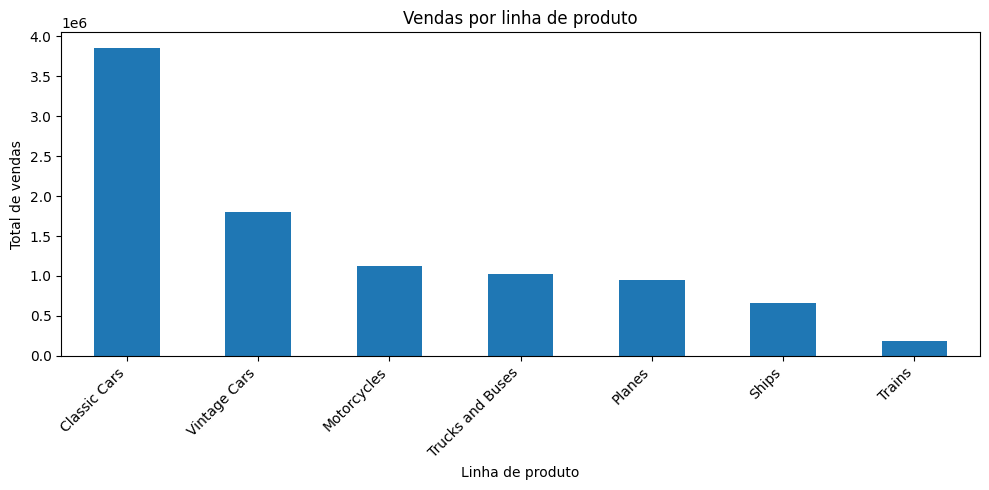

In [4]:
ax = sales_by_product_line.plot(kind='bar', x='product_line', y='total_sales', legend=False, figsize=(10,5))
ax.set_title('Vendas por linha de produto')
ax.set_xlabel('Linha de produto')
ax.set_ylabel('Total de vendas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 2. Vendas por país


In [5]:
sales_by_country = query_athena('''
SELECT
    c.country,
    ROUND(SUM(f.sales_amount), 2) AS total_sales
FROM fact_orders f
JOIN dim_countries c ON f.country_key = c.country_key
GROUP BY c.country
ORDER BY total_sales DESC
LIMIT 10
''')
sales_by_country['total_sales'] = sales_by_country['total_sales'].astype(float)
sales_by_country


,country,total_sales
0,USA,3273280.05
1,Spain,1099389.09
2,France,1007374.02
3,Australia,562582.59
4,New Zealand,476847.01
5,UK,436947.44
6,Italy,360616.81
7,Finland,295149.35
8,Singapore,263997.78
9,Denmark,218994.92


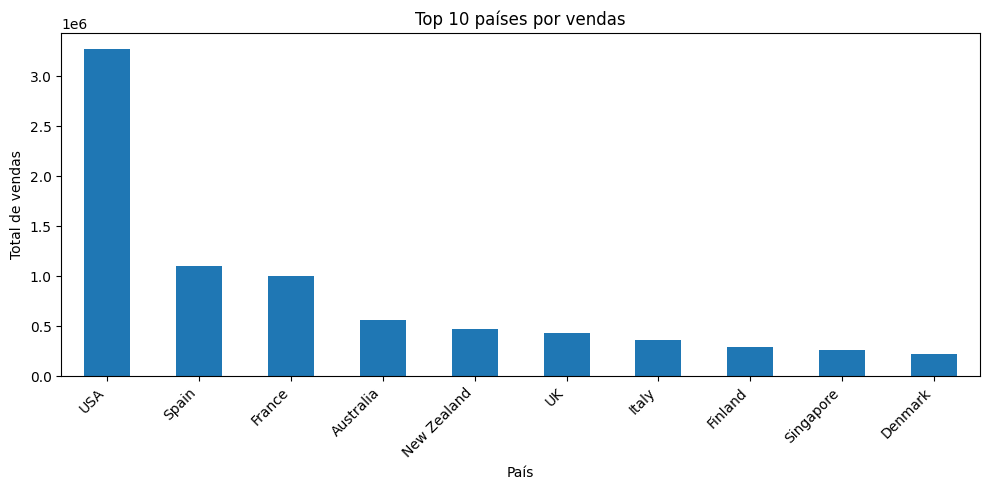

In [6]:
ax = sales_by_country.plot(kind='bar', x='country', y='total_sales', legend=False, figsize=(10,5))
ax.set_title('Top 10 países por vendas')
ax.set_xlabel('País')
ax.set_ylabel('Total de vendas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Vendas por mês


In [7]:
sales_by_month = query_athena('''
SELECT
    d.year,
    d.month,
    ROUND(SUM(f.sales_amount), 2) AS total_sales
FROM fact_orders f
JOIN dim_dates d ON f.order_date_key = d.date_key
GROUP BY d.year, d.month
ORDER BY d.year, d.month
''')
sales_by_month['total_sales'] = sales_by_month['total_sales'].astype(float)
sales_by_month['period'] = sales_by_month['year'].astype(str) + '-' + sales_by_month['month'].astype(str).str.zfill(2)
sales_by_month


,year,month,total_sales,period
0,2003,1,116692.77,2003-01
1,2003,2,128403.64,2003-02
2,2003,3,160517.14,2003-03
3,2003,4,185848.59,2003-04
4,2003,5,179435.55,2003-05
5,2003,6,150470.77,2003-06
6,2003,7,201940.36,2003-07
7,2003,8,178257.11,2003-08
8,2003,9,236697.85,2003-09
9,2003,10,514336.21,2003-10


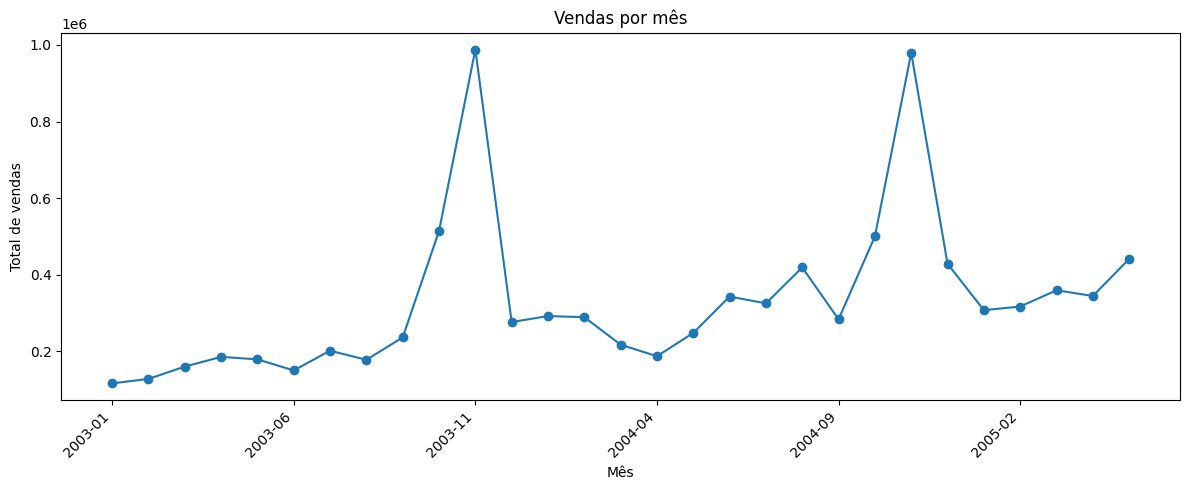

In [8]:
ax = sales_by_month.plot(kind='line', x='period', y='total_sales', marker='o', legend=False, figsize=(12,5))
ax.set_title('Vendas por mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Total de vendas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Top clientes por faturamento


In [9]:
top_customers = query_athena('''
SELECT
    c.customer_name,
    c.country,
    ROUND(SUM(f.sales_amount), 2) AS total_sales
FROM fact_orders f
JOIN dim_customers c ON f.customer_id = c.customer_id
GROUP BY c.customer_name, c.country
ORDER BY total_sales DESC
LIMIT 10
''')
top_customers['total_sales'] = top_customers['total_sales'].astype(float)
top_customers


,customer_name,country,total_sales
0,Euro+ Shopping Channel,Spain,820689.54
1,Mini Gifts Distributors Ltd.,USA,591827.34
2,"Australian Collectors, Co.",Australia,180585.07
3,Muscle Machine Inc,USA,177913.95
4,La Rochelle Gifts,France,158573.12
5,"Dragon Souveniers, Ltd.",Singapore,156251.03
6,"Down Under Souveniers, Inc",New Zealand,154622.08
7,Land of Toys Inc.,USA,149085.15
8,"AV Stores, Co.",UK,148410.09
9,The Sharp Gifts Warehouse,USA,143536.27
